# Project 3 — Customer Segmentation via K-Means Clustering

**Pipeline:** Data Loading & Validation → Feature Selection → Preprocessing/Scaling → PCA → 2D/3D Visualization → K-Means Clustering → Elbow Method + Silhouette Score → Select K → Final K-Means Model → Cluster Profiles → Business Personas → Business Insights & Recommendations

**Input:** `cleaned_dataset_project1.csv` (the cleaned output of Project 1) — 1,200 e-commerce orders.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

print("Libraries loaded.")

Libraries loaded.


## 1. Data Loading & Validation

In [2]:
df = pd.read_csv("cleaned_dataset_project1.csv", parse_dates=["Date"])

print(f"Shape: {df.shape}")
print(f"\nColumns:\n{list(df.columns)}")

Shape: (1200, 20)

Columns:
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice', 'PricePerItem', 'UsedCoupon', 'OrderMonth', 'OrderYear', 'CalculatedTotal', 'TotalPriceDifference']


In [3]:
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing values")
print()
print("Duplicate OrderIDs:", df['OrderID'].duplicated().sum())
print("Unique customers:", df['CustomerID'].nunique(), " / Total orders:", len(df))
print()
print("Date range:", df['Date'].min().date(), "to", df['Date'].max().date())
print()
print("OrderStatus values:", df['OrderStatus'].unique().tolist())
print("PaymentMethod values:", df['PaymentMethod'].unique().tolist())
print("Product values:", df['Product'].unique().tolist())

Missing values per column:
0 total missing values

Duplicate OrderIDs: 0
Unique customers: 1189  / Total orders: 1200

Date range: 2023-01-01 to 2025-06-30

OrderStatus values: ['Shipped', 'Cancelled', 'Returned', 'Delivered', 'Pending']
PaymentMethod values: ['Debit Card', 'Online', 'Credit Card', 'Gift Card', 'Cash']
Product values: ['Monitor', 'Phone', 'Tablet', 'Chair', 'Printer', 'Laptop', 'Desk']


**Validation note:** every customer has essentially one order (1,189 unique customers across 1,200 orders,
max 2 orders for any single customer). This matters for the next step — classic RFM "Frequency" will be
almost constant, so the segmentation below leans on **spend level and purchase behavior** rather than
repeat-purchase loyalty.

## 2. Feature Selection

We aggregate the order-level data to **one row per customer** (business personas describe customers,
not individual transactions). We build RFM-style behavioral features plus purchase-pattern features,
and one-hot encode each customer's preferred product category and payment method.

In [4]:
ref_date = df['Date'].max() + pd.Timedelta(days=1)

customer_df = df.groupby('CustomerID').agg(
    Recency=('Date', lambda x: (ref_date - x.max()).days),
    Frequency=('OrderID', 'count'),
    Monetary=('TotalPrice', 'sum'),
    AvgQuantity=('Quantity', 'mean'),
    AvgUnitPrice=('UnitPrice', 'mean'),
    AvgItemsInCart=('ItemsInCart', 'mean'),
    CouponUsageRate=('UsedCoupon', 'mean'),
    ProductDiversity=('Product', 'nunique'),
    CancelReturnRate=('OrderStatus', lambda x: x.isin(['Cancelled', 'Returned']).mean()),
    PreferredProduct=('Product', lambda x: x.mode().iloc[0]),
    PreferredPayment=('PaymentMethod', lambda x: x.mode().iloc[0]),
).reset_index()

customer_df['AvgOrderValue'] = customer_df['Monetary'] / customer_df['Frequency']

print(f"Customer-level table: {customer_df.shape[0]} customers x {customer_df.shape[1]} columns")
customer_df.head()

Customer-level table: 1189 customers x 13 columns


,CustomerID,Recency,Frequency,Monetary,AvgQuantity,AvgUnitPrice,AvgItemsInCart,CouponUsageRate,ProductDiversity,CancelReturnRate,PreferredProduct,PreferredPayment,AvgOrderValue
0,C10002,624,1,1470.03,3.0,490.01,4.0,1.0,1,1.0,Printer,Cash,1470.03
1,C10054,260,1,153.48,2.0,76.74,7.0,1.0,1,1.0,Laptop,Cash,153.48
2,C10126,744,1,1349.80,2.0,674.90,4.0,1.0,1,0.0,Monitor,Online,1349.80
3,C10154,337,1,1303.04,4.0,325.76,8.0,1.0,1,0.0,Desk,Gift Card,1303.04
4,C10211,418,1,635.90,5.0,127.18,10.0,1.0,1,1.0,Desk,Debit Card,635.90


In [5]:
numeric_features = ['Recency', 'Monetary', 'AvgOrderValue', 'AvgQuantity', 'AvgUnitPrice',
                     'AvgItemsInCart', 'CouponUsageRate', 'ProductDiversity', 'CancelReturnRate']
categorical_features = ['PreferredProduct', 'PreferredPayment']

X_num = customer_df[numeric_features].copy()
X_cat = pd.get_dummies(customer_df[categorical_features], prefix=categorical_features)
X = pd.concat([X_num, X_cat], axis=1)

print(f"Final feature matrix: {X.shape[0]} customers x {X.shape[1]} features")
print(f"\nFeatures used:\n{X.columns.tolist()}")

Final feature matrix: 1189 customers x 21 features

Features used:
['Recency', 'Monetary', 'AvgOrderValue', 'AvgQuantity', 'AvgUnitPrice', 'AvgItemsInCart', 'CouponUsageRate', 'ProductDiversity', 'CancelReturnRate', 'PreferredProduct_Chair', 'PreferredProduct_Desk', 'PreferredProduct_Laptop', 'PreferredProduct_Monitor', 'PreferredProduct_Phone', 'PreferredProduct_Printer', 'PreferredProduct_Tablet', 'PreferredPayment_Cash', 'PreferredPayment_Credit Card', 'PreferredPayment_Debit Card', 'PreferredPayment_Gift Card', 'PreferredPayment_Online']


## 3. Preprocessing / Scaling

K-Means and PCA are both distance-based, so every feature must be on the same scale. We standardize (zero mean, unit variance) before anything else.

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled feature matrix shape:", X_scaled.shape)
print("Mean (should be ~0):", np.round(X_scaled.mean(axis=0)[:5], 3))
print("Std  (should be ~1):", np.round(X_scaled.std(axis=0)[:5], 3))

Scaled feature matrix shape: (1189, 21)
Mean (should be ~0): [-0.  0. -0.  0. -0.]
Std  (should be ~1): [1. 1. 1. 1. 1.]


## 4. PCA

Components needed for 90% variance: 15 (out of 21 total features)


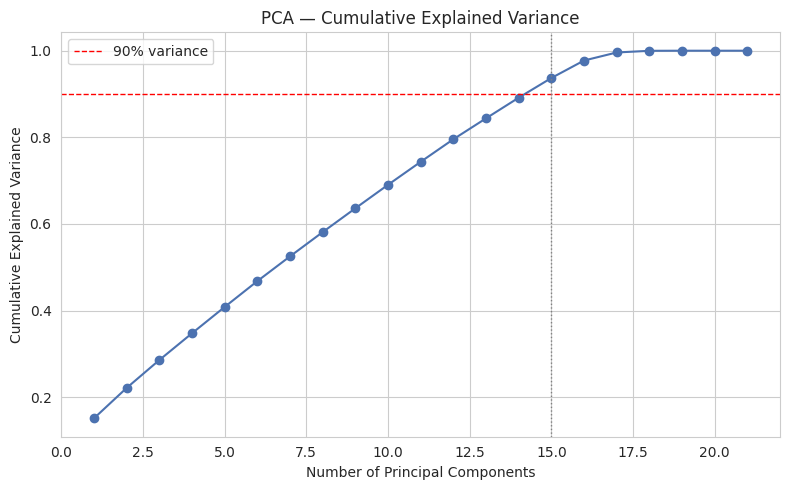

In [7]:
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = np.argmax(cum_var >= 0.90) + 1
print(f"Components needed for 90% variance: {n_90} (out of {X_scaled.shape[1]} total features)")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(cum_var)+1), cum_var, marker='o', color='#4C72B0')
ax.axhline(0.90, color='red', linestyle='--', linewidth=1, label='90% variance')
ax.axvline(n_90, color='gray', linestyle=':', linewidth=1)
ax.set_xlabel('Number of Principal Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.set_title('PCA — Cumulative Explained Variance')
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
# Reduce to components explaining 90% of variance -> used for clustering
pca = PCA(n_components=0.90, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print(f"Reduced from {X_scaled.shape[1]} features to {X_pca.shape[1]} principal components")
print(f"Variance explained by first 3 PCs: {pca.explained_variance_ratio_[:3].round(3)}")

Reduced from 21 features to 15 principal components
Variance explained by first 3 PCs: [0.151 0.07  0.064]


## 5. 2D / 3D Visualization

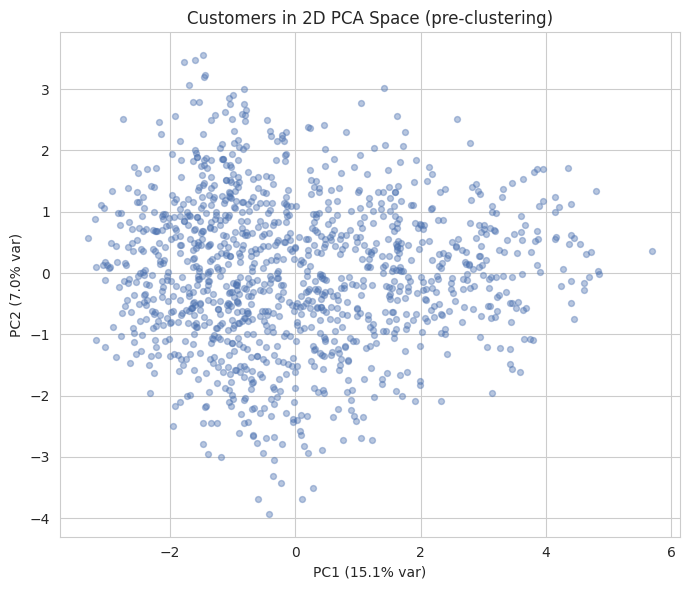

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.4, s=18, color='#4C72B0')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('Customers in 2D PCA Space (pre-clustering)')
plt.tight_layout()
plt.show()

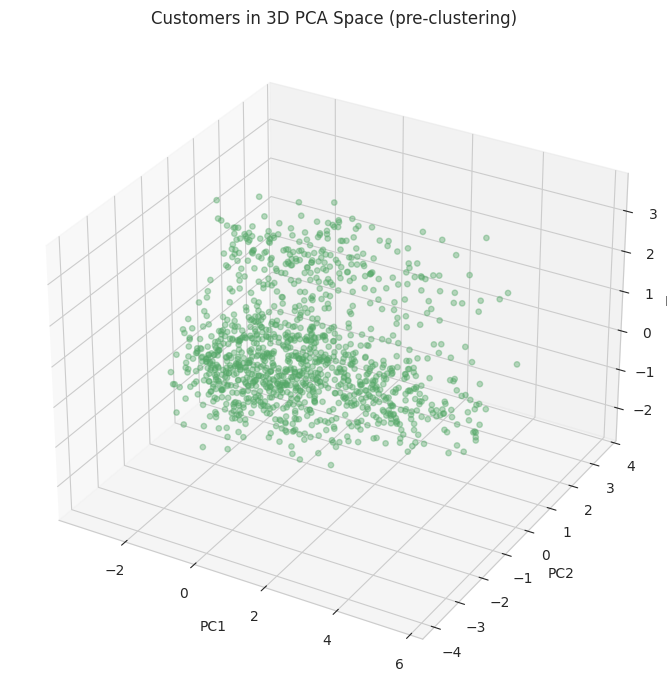

In [10]:
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], alpha=0.4, s=15, color='#55A868')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
ax.set_title('Customers in 3D PCA Space (pre-clustering)')
plt.tight_layout()
plt.show()

## 6. K-Means Clustering — Elbow Method & Silhouette Score

Clustering is performed on the PCA-reduced feature space. We try K = 2..10 and evaluate both criteria.

In [11]:
K_range = range(2, 11)
inertias, sil_scores = [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))

results = pd.DataFrame({'K': list(K_range), 'Inertia': inertias, 'Silhouette': sil_scores})
results

,K,Inertia,Silhouette
0,2,20730.972122,0.114611
1,3,19611.553011,0.094485
2,4,18506.953376,0.110929
3,5,17429.151490,0.125509
4,6,16404.614404,0.154974
5,7,15350.463808,0.178918
6,8,14205.107630,0.205823
7,9,13878.405829,0.198383
8,10,13099.332429,0.185177


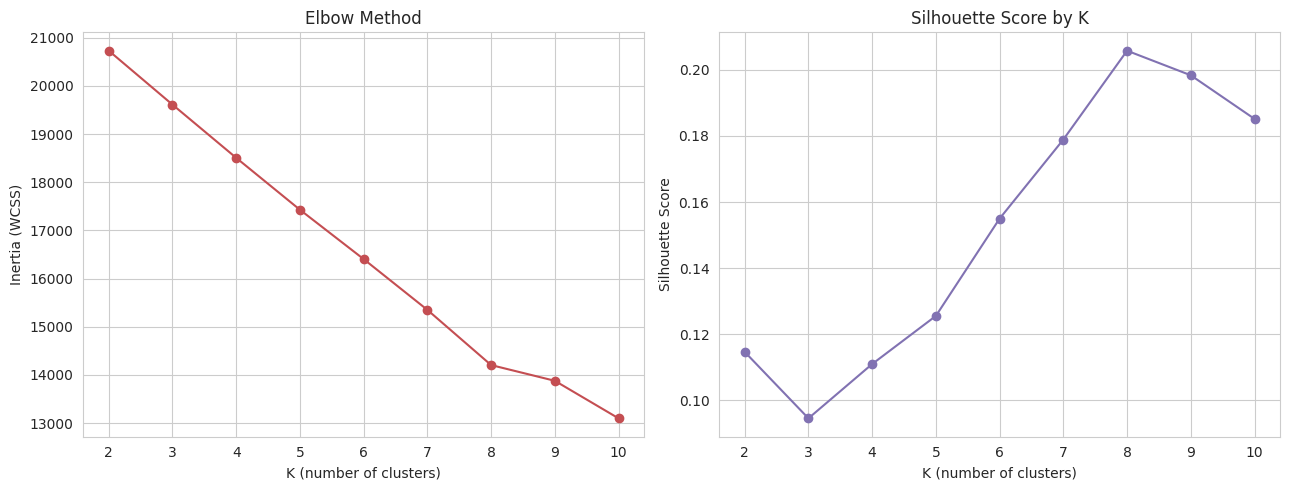

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(K_range, inertias, marker='o', color='#C44E52')
axes[0].set_xlabel('K (number of clusters)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method')

axes[1].plot(K_range, sil_scores, marker='o', color='#8172B2')
axes[1].set_xlabel('K (number of clusters)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by K')

plt.tight_layout()
plt.show()

### Select K

The elbow curve decreases smoothly with no sharp "knee" — a sign that natural cluster boundaries in this
dataset are soft rather than well-separated (consistent with this being a largely synthetic/randomly
generated dataset). Silhouette score rises gradually and peaks around **K=8** (~0.21), but the gain from
K=4 onward is incremental, not a step change.

**We select K = 4** as the working model: it captures the main structure visible in both charts (the biggest
drop in inertia has already happened by K=4, and silhouette at K=4 is a reasonable ~0.11) while keeping
the resulting personas small enough for a business team to act on. K=8 is noted as an alternative if
finer-grained segmentation is later needed.

## 7. Final K-Means Model

In [13]:
FINAL_K = 4
kmeans_final = KMeans(n_clusters=FINAL_K, random_state=RANDOM_STATE, n_init=10)
customer_df['Cluster'] = kmeans_final.fit_predict(X_pca)

print("Cluster sizes:")
print(customer_df['Cluster'].value_counts().sort_index())
print(f"\nFinal silhouette score at K={FINAL_K}: {silhouette_score(X_pca, customer_df['Cluster']):.4f}")

Cluster sizes:
Cluster
0    481
1    303
2    206
3    199
Name: count, dtype: int64

Final silhouette score at K=4: 0.1109


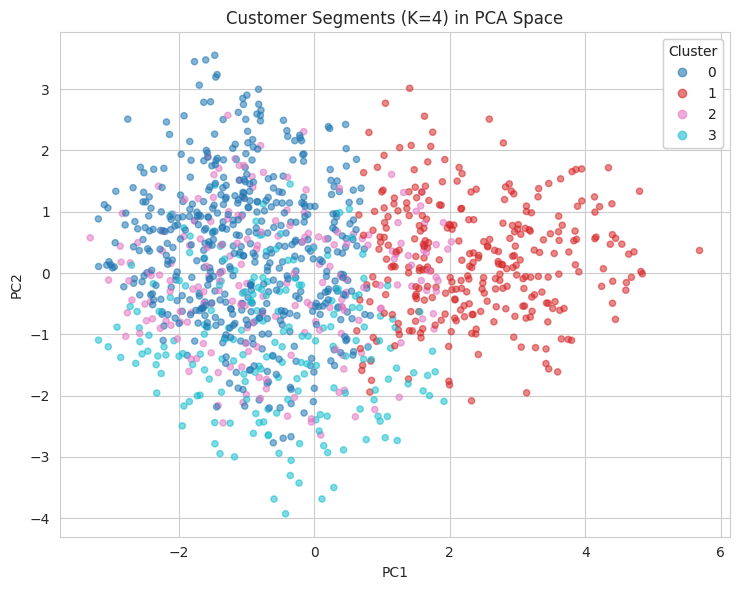

In [14]:
fig, ax = plt.subplots(figsize=(7.5, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=customer_df['Cluster'], cmap='tab10', alpha=0.55, s=20)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title(f'Customer Segments (K={FINAL_K}) in PCA Space')
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster", loc="best")
ax.add_artist(legend1)
plt.tight_layout()
plt.show()

## 8. Cluster Profiles

In [15]:
profile = customer_df.groupby('Cluster')[numeric_features + ['AvgOrderValue']].mean().round(2)
sizes = customer_df['Cluster'].value_counts().sort_index()
profile.insert(0, 'Size', sizes)
profile.insert(1, 'PctOfCustomers', (sizes / len(customer_df) * 100).round(1))
profile

,Size,PctOfCustomers,Recency,Monetary,AvgOrderValue,AvgQuantity,AvgUnitPrice,AvgItemsInCart,CouponUsageRate,ProductDiversity,CancelReturnRate,AvgOrderValue
Cluster,,,,,,,,,,,,
0,481,40.5,447.94,593.80,593.80,2.35,292.72,4.66,0.74,1.00,0.41,593.80
1,303,25.5,487.98,2190.17,2180.83,4.20,527.84,7.05,0.75,1.00,0.41,2180.83
2,206,17.3,454.40,833.93,821.25,2.68,323.15,5.23,0.73,1.00,0.42,821.25
3,199,16.7,471.95,720.31,698.73,2.75,285.92,5.39,0.75,1.03,0.43,698.73


In [16]:
print("Preferred product by cluster:")
display(pd.crosstab(customer_df['Cluster'], customer_df['PreferredProduct']))
print("\nPreferred payment method by cluster:")
display(pd.crosstab(customer_df['Cluster'], customer_df['PreferredPayment']))

Preferred product by cluster:


PreferredProduct,Chair,Desk,Laptop,Monitor,Phone,Printer,Tablet
Cluster,,,,,,,
0,73,64,60,62,77,73,72
1,45,47,42,44,33,47,45
2,29,32,32,28,25,29,31
3,31,27,38,26,19,31,27



Preferred payment method by cluster:


PreferredPayment,Cash,Credit Card,Debit Card,Gift Card,Online
Cluster,,,,,
0,0,150,0,145,186
1,50,82,23,82,66
2,0,0,206,0,0
3,195,2,0,1,1


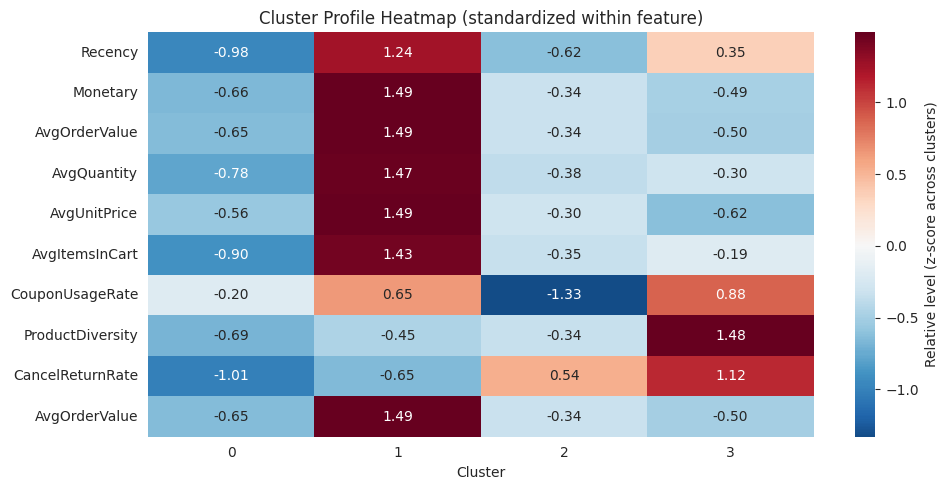

In [17]:
profile_z = customer_df.groupby('Cluster')[numeric_features + ['AvgOrderValue']].mean()
profile_z = (profile_z - profile_z.mean()) / profile_z.std()

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(profile_z.T, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            cbar_kws={'label': 'Relative level (z-score across clusters)'})
ax.set_title('Cluster Profile Heatmap (standardized within feature)')
ax.set_xlabel('Cluster')
plt.tight_layout()
plt.show()

## 9. Business Personas

Based on the cluster profiles above, the payment method and spend-level features are the strongest
differentiators (product preference and coupon usage are essentially flat across clusters in this dataset).
This gives us four personas:

| Cluster | Persona | Size | Profile |
|---|---|---|---|
| **0** | **Everyday Digital Shoppers** | 481 (40.5%) | Moderate spend (~$594 avg order), pays by Credit Card / Gift Card / Online. The largest, "default" segment. |
| **1** | **High-Value Power Buyers** | 303 (25.5%) | Highest spend by far (~$2,190 avg order, largest basket sizes and highest unit prices). Mixed payment methods. The most valuable segment per customer. |
| **2** | **Debit-Card Loyalists** | 206 (17.3%) | Exclusively pays by Debit Card. Mid-range spend (~$834 avg order), otherwise similar to Cluster 0. |
| **3** | **Cash-Preferred Value Shoppers** | 199 (16.7%) | Exclusively pays Cash. Lowest average unit price (~$286), moderate order value (~$720). |

**Flat across all four personas:** coupon usage (~73–75%), cancel/return rate (~41–43%), product-category
preference, and recency. These are *not* segmentation drivers here — they're closer to uniform,
company-wide patterns (see insights below).

## 10. Business Insights & Recommendations

**1. High-Value Power Buyers (25.5% of customers) punch far above their weight.**
Their average order value (~$2,190) is roughly 2–3x every other segment. Protect and grow this segment first:
a VIP/loyalty tier, dedicated account support, and early access to new products would likely have the
highest ROI of any single action here.

**2. Payment method is a stronger natural split than product taste.**
Debit-card and cash-preferring customers form their own clean segments, while product category preference
is essentially even across all four personas. This suggests checkout experience and payment-specific
incentives (e.g., a small debit-card cashback, or a "reserve for cash pickup" option) may move behavior
more than product-based merchandising.

**3. The ~41–43% cancel/return rate is a company-wide problem, not a segment problem.**
Because it's flat across every persona, this points to a systemic issue — fulfillment accuracy, product
description quality, or delivery reliability — rather than something that can be fixed by targeting one
customer group.

**4. Coupon usage (~74%) is high and uniform across all segments — a sign of margin risk.**
Since discounting isn't differentiating segments today, blanket coupon strategies are likely leaving
money on the table for full-price-tolerant customers (especially Cluster 1). Consider moving toward
targeted, tiered promotions instead of broad codes like `SAVE10`.

**5. Near-universal single-purchase behavior (avg. 1.01 orders/customer) is the biggest structural finding.**
With almost no repeat customers in the dataset, the real opportunity isn't just "which segment to sell more
to" — it's converting *any* segment into repeat buyers. A post-purchase email/retention flow, timed around
each persona's typical order value, is likely the highest-leverage recommendation overall.

**6. Segment boundaries are soft (silhouette ≈ 0.11–0.21), so treat personas as directional, not rigid.**
This is common with behavioral data that lacks strong natural clusters. If available, adding richer
behavioral signals (browsing activity, time-between-visits, customer service contacts) would likely sharpen
these segments for a production segmentation model.